In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from typing import Literal
from pydantic import BaseModel
import yfinance as yf
from langgraph.prebuilt import create_react_agent,ToolNode,tools_condition
from dotenv import load_dotenv

c:\Users\akash\OneDrive\Desktop\finance_analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_tavily import TavilySearch

In [3]:
load_dotenv()

True

NORMAL LLM

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

 NEWS TOOLS

In [5]:
news_tool = TavilySearch(
    max_results=5,
    topic="news"
)

STATE

In [78]:
from typing import TypedDict, Annotated
import operator

class FinancialState(TypedDict):

    # User Input
    query: str

    # Company Info
    company: str
    ticker: str

    # Parallel agent outputs
    market_result: dict
    news_result: dict
    rag_result: dict

    # Combined outputs (created by Barrier)
    agent_outputs: dict

    #risk agent
    risk_result: dict

    #investment result
    investment_result: dict

    # Final report
    final_report: str

    # Conversation history
    messages: Annotated[list, operator.add]

PYDANTIC MODEL

In [53]:
class RouteDecision(BaseModel):
    route: Literal[
        "market_agent",
        "rag_agent",
        "news_agent"
    ]

In [54]:
class CompanyExtraction(BaseModel):
    company: str

STRUCTURE MODEL

In [55]:
router_llm = llm.with_structured_output(RouteDecision)

In [56]:
extractor_llm = llm.with_structured_output(
    CompanyExtraction
)

HELPER FUNCTION

In [57]:
def fetch_company_info(symbol: str):

    stock = yf.Ticker(symbol)

    return stock.info

RAG COMPONENTS

In [12]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

C:\Users\akash\AppData\Local\Temp\ipykernel_11280\170880071.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [13]:
def load_financial_report(file_path: str):
    loader = PyPDFLoader(file_path)
    documents = loader.load()
    return documents

In [14]:
docs = load_financial_report(
    "data/reports/Apple_2025_Annual_Report.pdf"
)

In [15]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [16]:
def split_documents(documents):
    chunks = text_splitter.split_documents(documents)
    return chunks

In [17]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1532.25it/s]


In [18]:
chunks = split_documents(docs)
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)


In [19]:
retriever = vector_store.as_retriever(
    search_kwargs={"k": 4}
)

TOOLS TO BE USED

In [20]:
@tool
def get_stock_data(ticker: str):
    """
    Fetch live stock information using Yahoo Finance.
    """
    try:
        info = fetch_company_info(ticker)

        return {
            "company": info.get("longName", "N/A"),
            "symbol": info.get("symbol", ticker),
            "current_price": info.get("currentPrice", "N/A"),
            "previous_close": info.get("previousClose", "N/A"),
            "market_cap": info.get("marketCap", "N/A"),
            "sector": info.get("sector", "N/A"),
            "industry": info.get("industry", "N/A"),
            "pe_ratio": info.get("trailingPE", "N/A"),
            "eps": info.get("trailingEps", "N/A"),
            "currency": info.get("currency", "N/A"),
        }

    except Exception as e:
        return {
            "error": str(e)
        }

In [21]:
@tool
def get_company_profile(ticker: str):
    """
    Fetch company profile information using Yahoo Finance.
    """

    info = fetch_company_info(ticker)

    return {
        "company": info.get("longName"),
        "industry": info.get("industry"),
        "sector": info.get("sector"),
        "website": info.get("website"),
        "country": info.get("country"),
        "employees": info.get("fullTimeEmployees"),
        "business_summary": info.get("longBusinessSummary"),
    }

In [22]:
@tool
def calculate_financial_ratios(ticker: str):
    """
    Fetch important financial ratios.
    """

    info = fetch_company_info(ticker)

    return {
        "pe_ratio": info.get("trailingPE"),
        "forward_pe": info.get("forwardPE"),
        "peg_ratio": info.get("pegRatio"),
        "price_to_book": info.get("priceToBook"),
        "profit_margin": info.get("profitMargins"),
        "operating_margin": info.get("operatingMargins"),
        "return_on_equity": info.get("returnOnEquity"),
        "return_on_assets": info.get("returnOnAssets"),
    }

In [23]:
@tool
def retrieve_financial_report(query: str):
    """
    Retrieve relevant information from financial reports.
    """

    docs = retriever.invoke(query)

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    return context

In [24]:
@tool
def retrieve_financial_report(query: str):
    """
    Retrieve relevant information from financial reports.
    """

    docs = retriever.invoke(query)

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    return context

REACT AGENT

In [25]:
market_react_agent = create_react_agent(
    model=llm,
    tools=[
        get_stock_data,
        get_company_profile,
        calculate_financial_ratios
    ]
)

C:\Users\akash\AppData\Local\Temp\ipykernel_11280\4053900193.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  market_react_agent = create_react_agent(


In [26]:
rag_react_agent = create_react_agent(
    model=llm,
    tools=[
        retrieve_financial_report
    ]
)

C:\Users\akash\AppData\Local\Temp\ipykernel_11280\2000636999.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  rag_react_agent = create_react_agent(


In [27]:
#News ReAct Agent
news_react_agent = create_react_agent(
    model=llm,
    tools=[
        news_tool
    ]
)

C:\Users\akash\AppData\Local\Temp\ipykernel_11280\1173907000.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  news_react_agent = create_react_agent(


NODE FUNCTION

In [80]:
def supervisor_agent(state: FinancialState):

    query = state["query"]

    prompt = f"""
You are the supervisor of a Financial Analysis Agent Crew.

Determine whether the following query is related to financial analysis.

Query:
{query}

Reply with ONLY:

YES

or

NO
"""

    answer = llm.invoke(prompt)

    print(answer.content)

    return state

In [82]:
def market_agent(state: FinancialState):

    ticker = state["ticker"]

    result = market_react_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"""
                            You are a professional financial analyst.

                            Analyze the company using the ticker:

                            {ticker}

                            Use your available tools whenever required.

                            After retrieving the data,

                            Provide:

                            1. Company Overview
                            2. Current Stock Price
                            3. Market Capitalization
                            4. Sector
                            5. Industry
                            6. P/E Ratio
                            7. EPS
                            8. Key Business Summary
                            Keep the response under 200 words.
                        """
                )
            ]
        }
    )

    final_answer = result["messages"][-1].content

    last_message = result["messages"][-1]

    if isinstance(last_message.content, list):
        final_answer = "\n".join(
            block["text"]
            for block in last_message.content
            if block.get("type") == "text"
        )
    else:
        final_answer = last_message.content

    market_output = {
    "analysis": final_answer,
    "ticker": ticker
    }

    return {
   "market_result": {
        "analysis": final_answer
    },
    "messages": result["messages"]
    }

In [83]:
def router(state: FinancialState):
    return state["route"]

In [84]:
def entity_extractor_agent(state: FinancialState):

    query = state["query"]
    prompt = f"""
        You are a financial entity extraction agent.

        Extract ONLY the company name mentioned.

        Examples

        Input:
        Should I invest in Apple?

        Output:
        Apple

        Input:
        Analyze Microsoft stock.

        Output:
        Microsoft

        Input:
        Tell me about Tesla.

        Output:
        Tesla

        User Query:

        {query}
    """

    result = extractor_llm.invoke(prompt)
    print(f"\nCompany: {result.company}")
    return {
        "company": result.company
    }

In [85]:
TICKER_MAP = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Google": "GOOGL",
    "Alphabet": "GOOGL",
    "Amazon": "AMZN",
    "Tesla": "TSLA",
    "Meta": "META",
    "NVIDIA": "NVDA",
    "Netflix": "NFLX",
    "Intel": "INTC",
    "AMD": "AMD",

    "Reliance": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
    "Wipro": "WIPRO.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "ICICI Bank": "ICICIBANK.NS",
}

In [86]:
def ticker_resolver_agent(state: FinancialState):

    company = state["company"]

    ticker = TICKER_MAP.get(company)

    if ticker is None:
        ticker = company

    print(f"\nTicker: {ticker}")

    return {
        "ticker": ticker
    }

In [87]:
def rag_agent(state: FinancialState):

    query = state["query"]

    result = rag_react_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"""
                        You are a financial report analyst.

                        Answer ONLY from the uploaded annual report.

                        If information is missing, explicitly say it is not present in the report.

                        Always provide:

                        • Direct answer
                        • Supporting evidence
                        • Relevant financial discussion

                        Question:

                        {query}

                        Use your retrieval tool whenever needed.

                        If the report doesn't contain the answer, clearly say so.
                        """
                )
            ]
        }
    )

    last_message = result["messages"][-1]

    if isinstance(last_message.content, list):
        final_answer = "\n".join(
            block["text"]
            for block in last_message.content
            if block.get("type") == "text"
        )
    else:
        final_answer = last_message.content

    return {
        "rag_result": {
            "analysis": final_answer
        },
        "messages": result["messages"]
    }

In [88]:
def news_agent(state: FinancialState):

    query = state["query"]

    result = news_react_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"""
                        You are a financial news analyst.

                        Find the latest news related to:

                        {query}

                        Use your search tool whenever required.

                        Provide:

                        1. Headlines
                        2. Summary
                        3. Possible market impact
                        4. Overall sentiment

                        Keep the answer concise.
                        """
                )
            ]
        }
    )

    last_message = result["messages"][-1]

    if isinstance(last_message.content, list):
        final_answer = "\n".join(
            block["text"]
            for block in last_message.content
            if block.get("type") == "text"
        )
    else:
        final_answer = last_message.content

    return {
         "news_result": {
            "analysis": final_answer
        },
        "messages": result["messages"]
    }

In [89]:
def risk_agent(state: FinancialState):

    market = state["agent_outputs"].get("market", {}).get("analysis", "")

    rag = state["agent_outputs"].get("rag", {}).get("analysis", "")

    news = state["agent_outputs"].get("news", {}).get("analysis", "")

    prompt = f"""
        You are a Senior Financial Risk Analyst.

        Evaluate the investment risk using the following information.

        ==========================
        MARKET ANALYSIS
        ==========================

        {market}

        ==========================
        FINANCIAL REPORT ANALYSIS
        ==========================

        {rag}

        ==========================
        LATEST NEWS
        ==========================

        {news}

        Generate a structured report containing:

        1. Overall Risk Level
        2. Financial Risk
        3. Business Risk
        4. Market Sentiment
        5. Key Risk Factors
        6. Strengths
        7. Weaknesses

        Keep the report concise.
        """

    answer = llm.invoke(prompt)

    return {
        "risk_result": {
            "analysis": answer.content
        }
    }

In [90]:
def investment_agent(state: FinancialState):

    outputs = state["agent_outputs"]

    market = outputs.get("market", {}).get("analysis", "")
    rag = outputs.get("rag", {}).get("analysis", "")
    news = outputs.get("news", {}).get("analysis", "")

    risk = state.get("risk_result", {}).get("analysis", "")

    prompt = f"""
    You are a Senior Investment Advisor.

    Based on the following analyses, provide an investment recommendation.

    =====================
    MARKET ANALYSIS
    =====================
    {market}

    =====================
    FINANCIAL REPORT ANALYSIS
    =====================
    {rag}

    =====================
    NEWS ANALYSIS
    =====================
    {news}

    =====================
    RISK ANALYSIS
    =====================
    {risk}

    Provide your response in the following format:

    1. Recommendation
    (Strong Buy / Buy / Hold / Sell / Strong Sell)

    2. Confidence
    (High / Medium / Low)

    3. Suitable For
    (Short-term / Long-term / Value Investor / Growth Investor)

    4. Key Reasons

    5. Potential Concerns

    Keep the response under 250 words.
    """

    answer = llm.invoke(prompt)

    return {
        "investment_result": {
            "analysis": answer.content
        }
    }

In [91]:
def report_generator(state: FinancialState):

    market = state.get("market_result", {}).get("analysis", "")

    news = state.get("news_result", {}).get("analysis", "")

    rag = state.get("rag_result", {}).get("analysis", "")

    risk = state.get("risk_result", {}).get("analysis", "")

    investment = state.get("investment_result", {}).get("analysis", "")

    prompt = f"""
You are a Chief Financial Analyst.

Create a professional financial analysis report.

================================================
MARKET ANALYSIS
================================================

{market}

================================================
FINANCIAL REPORT ANALYSIS
================================================

{rag}

================================================
NEWS ANALYSIS
================================================

{news}

================================================
RISK ANALYSIS
================================================

{risk}

================================================
INVESTMENT RECOMMENDATION
================================================

{investment}

Create a professional report with the following sections:

# Executive Summary

# Company Overview

# Market Performance

# Financial Analysis

# Business Analysis

# Recent News

# Risk Assessment

# Investment Recommendation

# Final Conclusion

Use professional language.

Keep the report around 600-800 words.
"""

    answer = llm.invoke(prompt)

    return {
        "final_report": answer.content
    }
    

In [92]:
def synchronization_barrier(state: FinancialState):

    print("=" * 60)
    print("All parallel agents completed.")
    print("=" * 60)

    return {
        "agent_outputs": {
            "market": state["market_result"],
            "news": state["news_result"],
            "rag": state["rag_result"],
        }
    }

GRAPH BUILDING

In [93]:
builder = StateGraph(FinancialState)

#nodes
builder.add_node("supervisor", supervisor_agent)
builder.add_node("market_agent", market_agent)
builder.add_node("entity_extractor",entity_extractor_agent)

builder.add_node("ticker_resolver",ticker_resolver_agent)
builder.add_node("rag_agent",rag_agent)
builder.add_node("news_agent",news_agent)

builder.add_node("barrier", synchronization_barrier)

builder.add_node("risk_agent", risk_agent)
builder.add_node("investment_agent", investment_agent)

builder.add_node("report_generator", report_generator)

#edges
builder.add_edge(START, "supervisor")
builder.add_edge("supervisor", "entity_extractor")
builder.add_edge("entity_extractor", "ticker_resolver")
builder.add_edge("ticker_resolver", "market_agent")
builder.add_edge("ticker_resolver", "news_agent")
builder.add_edge("ticker_resolver", "rag_agent")
builder.add_edge("market_agent", "barrier")
builder.add_edge("news_agent", "barrier")
builder.add_edge("rag_agent", "barrier")
builder.add_edge("barrier", "risk_agent")
builder.add_edge("risk_agent", "investment_agent")
builder.add_edge("investment_agent", "report_generator")
builder.add_edge("report_generator", END)


graph = builder.compile()

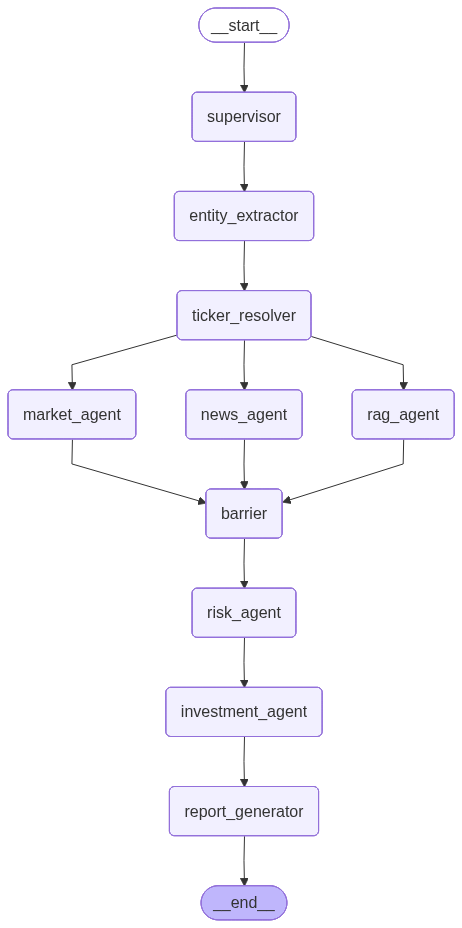

In [73]:
graph

In [94]:
query = "Analyze Apple"

result = graph.invoke(
    {
        "query": query,
        "company": "",
        "ticker": "",
        "market_result": {},
        "news_result": {},
        "rag_result": {},
        "agent_outputs": {},
        "risk_result": {},
        "investment_result": {},
        "final_report": "",
        "messages": []
    }
)

YES

Company: Apple

Ticker: AAPL
All parallel agents completed.


In [96]:
print(result["final_report"])

# Executive Summary
This report provides a comprehensive analysis of Apple Inc., a leading technology company that designs, manufactures, and markets a range of consumer electronics, software, and services. Our analysis covers the company's market performance, financials, business operations, recent news, and risk assessment. Based on our findings, we recommend a "Buy" rating for Apple Inc., with a medium confidence level, suitable for long-term growth investors.

# Company Overview
Apple Inc. is a multinational technology company that offers a diverse range of products and services, including iPhones, Macs, iPads, wearables, and accessories, as well as various subscription-based services like Apple Arcade, Apple Fitness+, and Apple Music. With a market capitalization of $4,323,665,937,536 and a current stock price of $294.38, Apple is one of the largest and most influential technology companies in the world.

# Market Performance
Apple's market performance has been strong, with a P/E 